# Mission 1: 굴뚝 위치 탐지 (Object Detection)

## 문제 개요
- Kompsat-3/3A 위성 이미지에서 굴뚝 위치를 바운딩 박스로 탐지
- YOLOv8 모델 사용
- mAP@IoU=0.5 지표로 평가
- Training: 8,052개, Validation: 1,006개

In [1]:

import torch
print(torch.__version__)
print('CUDA available?', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

import torch
print(torch.__version__)
print('CUDA available?', torch.cuda.is_available())
print('CUDA ver:', torch.version.cuda)
print('Device count:', torch.cuda.device_count())
print('Device name:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')



2.3.1+cu121
CUDA available? True
Device: NVIDIA GeForce RTX 3060
2.3.1+cu121
CUDA available? True
CUDA ver: 12.1
Device count: 1
Device name: NVIDIA GeForce RTX 3060


In [2]:
import os
import json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
from ultralytics import YOLO
import torch
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# 랜덤 시드 고정
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.3.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3060


## 1. 데이터 경로 설정 및 확인

In [3]:
# 데이터 경로 설정 - 상대 경로로 수정
BASE_PATH = r"..\53.대기오염 배출원 공간 분포 데이터\3.개방데이터\1.데이터"

# 이미지 경로
TRAIN_IMG_PATH = r"..\53.대기오염 배출원 공간 분포 데이터\3.개방데이터\1.데이터\Training\01.원천데이터\TS_KS"
VAL_IMG_PATH = r"..\53.대기오염 배출원 공간 분포 데이터\3.개방데이터\1.데이터\Validation\01.원천데이터\VS_KS"

# 라벨 경로
TRAIN_LABEL_PATH = r"..\53.대기오염 배출원 공간 분포 데이터\3.개방데이터\1.데이터\Training\02.라벨링데이터\TL_KS_BBOX"
VAL_LABEL_PATH = r"..\53.대기오염 배출원 공간 분포 데이터\3.개방데이터\1.데이터\Validation\02.라벨링데이터\VL_KS_BBOX"

# YOLO 데이터셋 구조 생성을 위한 경로 - mission1 내부로 변경
YOLO_DATASET_PATH = "yolo_dataset"

print(f"Training images: {TRAIN_IMG_PATH}")
print(f"Training labels: {TRAIN_LABEL_PATH}")
print(f"Validation labels: {VAL_LABEL_PATH}")

# 경로 존재 확인
print(f"\nPath checks:")
print(f"Train images exist: {os.path.exists(TRAIN_IMG_PATH)}")
print(f"Train labels exist: {os.path.exists(TRAIN_LABEL_PATH)}")
print(f"Val labels exist: {os.path.exists(VAL_LABEL_PATH)}")

Training images: ..\53.대기오염 배출원 공간 분포 데이터\3.개방데이터\1.데이터\Training\01.원천데이터\TS_KS
Training labels: ..\53.대기오염 배출원 공간 분포 데이터\3.개방데이터\1.데이터\Training\02.라벨링데이터\TL_KS_BBOX
Validation labels: ..\53.대기오염 배출원 공간 분포 데이터\3.개방데이터\1.데이터\Validation\02.라벨링데이터\VL_KS_BBOX

Path checks:
Train images exist: True
Train labels exist: True
Val labels exist: True


## 2. 데이터 분석 및 탐색

In [4]:
# 이미지 파일 수 확인
train_images = [f for f in os.listdir(TRAIN_IMG_PATH) if f.endswith('.jpg')]
print(f"Total training images: {len(train_images)}")

# 라벨 파일 수 확인
train_labels = [f for f in os.listdir(TRAIN_LABEL_PATH) if f.endswith('.json')]
print(f"Total training labels: {len(train_labels)}")

# 샘플 라벨 파일 분석
sample_label_file = os.path.join(TRAIN_LABEL_PATH, train_labels[0])
with open(sample_label_file, 'r', encoding='utf-8') as f:
    sample_data = json.load(f)

print(f"\nSample label structure:")
print(json.dumps(sample_data, indent=2, ensure_ascii=False)[:500] + "...")

Total training images: 8052
Total training labels: 8052

Sample label structure:
{
  "K3A_CHN_20161112052404_0.jpg63669": {
    "filename": "K3A_CHN_20161112052404_0.jpg",
    "size": 63669,
    "regions": [
      {
        "shape_attributes": {
          "name": "rect",
          "x": 107,
          "y": 364,
          "width": 86,
          "height": 18
        },
        "region_attributes": {
          "chi_id": "1"
        }
      },
      {
        "shape_attributes": {
          "name": "rect",
          "x": 219,
          "y": 387,
          "width": 76,
          "...


In [5]:
# 라벨 데이터 분석 함수
def analyze_labels(label_path):
    label_files = [f for f in os.listdir(label_path) if f.endswith('.json')]
    total_objects = 0
    images_with_objects = 0
    bbox_stats = []
    
    for label_file in label_files:
        with open(os.path.join(label_path, label_file), 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # JSON 구조에서 regions 추출
        for key in data:
            if 'regions' in data[key]:
                regions = data[key]['regions']
                if regions:
                    images_with_objects += 1
                    total_objects += len(regions)
                    
                    # 바운딩 박스 크기 통계
                    for region in regions:
                        if 'shape_attributes' in region:
                            shape = region['shape_attributes']
                            if shape.get('name') == 'rect':
                                bbox_stats.append({
                                    'width': shape.get('width', 0),
                                    'height': shape.get('height', 0),
                                    'x': shape.get('x', 0),
                                    'y': shape.get('y', 0)
                                })
    
    return {
        'total_images': len(label_files),
        'images_with_objects': images_with_objects,
        'total_objects': total_objects,
        'avg_objects_per_image': total_objects / len(label_files) if label_files else 0,
        'bbox_stats': bbox_stats
    }

# 학습 데이터 분석
train_analysis = analyze_labels(TRAIN_LABEL_PATH)
print("Training Data Analysis:")
print(f"Total images: {train_analysis['total_images']}")
print(f"Images with objects: {train_analysis['images_with_objects']}")
print(f"Total objects: {train_analysis['total_objects']}")
print(f"Average objects per image: {train_analysis['avg_objects_per_image']:.2f}")

# 바운딩 박스 통계
if train_analysis['bbox_stats']:
    bbox_df = pd.DataFrame(train_analysis['bbox_stats'])
    print(f"\nBounding Box Statistics:")
    print(bbox_df.describe())

Training Data Analysis:
Total images: 8052
Images with objects: 8052
Total objects: 10619
Average objects per image: 1.32

Bounding Box Statistics:
              width        height             x             y
count  10619.000000  10619.000000  10619.000000  10619.000000
mean      68.163481     44.587155    228.327997    237.497410
std       37.214854     35.094561    134.735008    138.039661
min        6.000000      5.000000      0.000000      0.000000
25%       42.000000     20.000000    102.000000    112.000000
50%       61.000000     32.000000    229.000000    227.000000
75%       85.000000     59.000000    350.000000    365.000000
max      334.000000    270.000000    491.000000    500.000000


## 3. 샘플 이미지 및 라벨 시각화

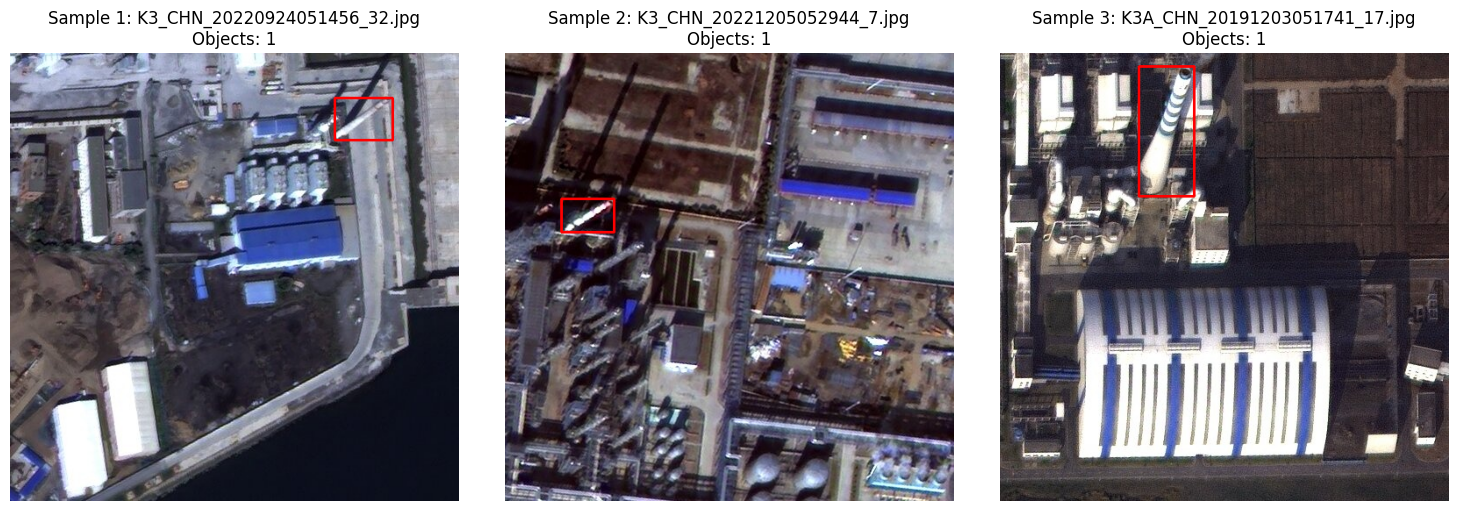

In [6]:
def visualize_sample(image_path, label_path, num_samples=3):
    """샘플 이미지와 바운딩 박스 시각화"""
    label_files = [f for f in os.listdir(label_path) if f.endswith('.json')]
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    if num_samples == 1:
        axes = [axes]
    
    for i in range(num_samples):
        # 랜덤 샘플 선택
        label_file = np.random.choice(label_files)
        
        # 라벨 데이터 로드
        with open(os.path.join(label_path, label_file), 'r', encoding='utf-8') as f:
            label_data = json.load(f)
        
        # 해당 이미지 파일명 추출
        img_filename = None
        regions = []
        
        for key in label_data:
            if 'filename' in label_data[key]:
                img_filename = label_data[key]['filename']
                regions = label_data[key].get('regions', [])
                break
        
        if not img_filename:
            continue
            
        # 이미지 로드
        img_path = os.path.join(image_path, img_filename)
        if not os.path.exists(img_path):
            continue
            
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # 바운딩 박스 그리기
        for region in regions:
            if 'shape_attributes' in region:
                shape = region['shape_attributes']
                if shape.get('name') == 'rect':
                    x, y = shape.get('x', 0), shape.get('y', 0)
                    w, h = shape.get('width', 0), shape.get('height', 0)
                    
                    # 바운딩 박스 그리기
                    cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)
        
        axes[i].imshow(image)
        axes[i].set_title(f'Sample {i+1}: {img_filename}\nObjects: {len(regions)}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# 샘플 시각화
visualize_sample(TRAIN_IMG_PATH, TRAIN_LABEL_PATH, 3)

## 4. YOLO 형식으로 데이터 변환

In [7]:
def create_yolo_dataset_structure():
    """YOLO 데이터셋 폴더 구조 생성"""
    os.makedirs(f"{YOLO_DATASET_PATH}/images/train", exist_ok=True)
    os.makedirs(f"{YOLO_DATASET_PATH}/images/val", exist_ok=True)
    os.makedirs(f"{YOLO_DATASET_PATH}/labels/train", exist_ok=True)
    os.makedirs(f"{YOLO_DATASET_PATH}/labels/val", exist_ok=True)

def convert_bbox_to_yolo(x, y, width, height, img_width, img_height):
    """바운딩 박스를 YOLO 형식으로 변환"""
    # 중심점 계산
    center_x = (x + width / 2) / img_width
    center_y = (y + height / 2) / img_height
    
    # 정규화된 width, height
    norm_width = width / img_width
    norm_height = height / img_height
    
    return center_x, center_y, norm_width, norm_height

def convert_json_to_yolo(json_path, output_label_path):
    """JSON 라벨을 YOLO 형식으로 변환"""
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # 이미지 정보 및 regions 추출
    for key in data:
        if 'regions' in data[key]:
            regions = data[key]['regions']
            img_width = int(data[key]['file_attributes'].get('img_width', 512))
            img_height = int(data[key]['file_attributes'].get('img_height', 512))
            
            yolo_annotations = []
            
            for region in regions:
                if 'shape_attributes' in region:
                    shape = region['shape_attributes']
                    if shape.get('name') == 'rect':
                        x = shape.get('x', 0)
                        y = shape.get('y', 0)
                        w = shape.get('width', 0)
                        h = shape.get('height', 0)
                        
                        # YOLO 형식으로 변환 (class_id=0, 굴뚝은 단일 클래스)
                        center_x, center_y, norm_w, norm_h = convert_bbox_to_yolo(
                            x, y, w, h, img_width, img_height
                        )
                        
                        yolo_annotations.append(f"0 {center_x:.6f} {center_y:.6f} {norm_w:.6f} {norm_h:.6f}")
            
            # YOLO 라벨 파일 저장
            with open(output_label_path, 'w') as f:
                f.write('\n'.join(yolo_annotations))
            
            break

# YOLO 데이터셋 구조 생성
create_yolo_dataset_structure()
print("YOLO dataset structure created")

YOLO dataset structure created


In [8]:
# 학습 데이터 변환
def process_dataset(image_source_path, label_source_path, image_dest_path, label_dest_path, dataset_type="train"):
    """데이터셋을 YOLO 형식으로 변환하고 복사"""
    label_files = [f for f in os.listdir(label_source_path) if f.endswith('.json')]
    processed_count = 0
    
    for label_file in label_files:
        # 라벨 파일에서 이미지 파일명 추출
        with open(os.path.join(label_source_path, label_file), 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        img_filename = None
        for key in data:
            if 'filename' in data[key]:
                img_filename = data[key]['filename']
                break
        
        if not img_filename:
            continue
        
        # 해당 이미지 파일이 존재하는지 확인
        source_img_path = os.path.join(image_source_path, img_filename)
        if not os.path.exists(source_img_path):
            continue
        
        # 이미지 복사
        dest_img_path = os.path.join(image_dest_path, img_filename)
        shutil.copy2(source_img_path, dest_img_path)
        
        # 라벨 변환 및 저장
        label_name = os.path.splitext(img_filename)[0] + '.txt'
        dest_label_path = os.path.join(label_dest_path, label_name)
        
        convert_json_to_yolo(
            os.path.join(label_source_path, label_file),
            dest_label_path
        )
        
        processed_count += 1
        
        if processed_count % 1000 == 0:
            print(f"Processed {processed_count} {dataset_type} samples")
    
    print(f"Completed {dataset_type} dataset: {processed_count} samples")
    return processed_count

# 학습 데이터 처리
train_count = process_dataset(
    TRAIN_IMG_PATH, 
    TRAIN_LABEL_PATH,
    f"{YOLO_DATASET_PATH}/images/train",
    f"{YOLO_DATASET_PATH}/labels/train",
    "train"
)

Processed 1000 train samples
Processed 2000 train samples
Processed 3000 train samples
Processed 4000 train samples
Processed 5000 train samples
Processed 6000 train samples
Processed 7000 train samples
Processed 8000 train samples
Completed train dataset: 8052 samples


In [9]:
# 검증 데이터 처리 (검증 라벨이 있는 경우)
if os.path.exists(VAL_LABEL_PATH):
    val_count = process_dataset(
        VAL_IMG_PATH,  # 검증 이미지 경로 수정
        VAL_LABEL_PATH,
        f"{YOLO_DATASET_PATH}/images/val",
        f"{YOLO_DATASET_PATH}/labels/val",
        "val"
    )
else:
    # 검증 라벨이 없는 경우 학습 데이터에서 일부 분할
    print("Validation labels not found. Splitting training data...")
    
    # 학습 데이터의 20%를 검증용으로 분할
    train_images = os.listdir(f"{YOLO_DATASET_PATH}/images/train")
    val_split = 0.2
    val_size = int(len(train_images) * val_split)
    
    np.random.shuffle(train_images)
    val_images = train_images[:val_size]
    
    # 검증 데이터 이동
    for img_name in val_images:
        # 이미지 이동
        src_img = f"{YOLO_DATASET_PATH}/images/train/{img_name}"
        dst_img = f"{YOLO_DATASET_PATH}/images/val/{img_name}"
        shutil.move(src_img, dst_img)
        
        # 라벨 이동
        label_name = os.path.splitext(img_name)[0] + '.txt'
        src_label = f"{YOLO_DATASET_PATH}/labels/train/{label_name}"
        dst_label = f"{YOLO_DATASET_PATH}/labels/val/{label_name}"
        if os.path.exists(src_label):
            shutil.move(src_label, dst_label)
    
    print(f"Split {len(val_images)} images for validation")

# 최종 데이터셋 크기 확인
final_train_count = len(os.listdir(f"{YOLO_DATASET_PATH}/images/train"))
final_val_count = len(os.listdir(f"{YOLO_DATASET_PATH}/images/val"))

print(f"\nFinal dataset sizes:")
print(f"Training: {final_train_count} images")
print(f"Validation: {final_val_count} images")

Processed 1000 val samples
Completed val dataset: 1006 samples

Final dataset sizes:
Training: 8052 images
Validation: 1006 images


## 5. YOLO 설정 파일 생성

In [10]:
# dataset.yaml 파일 생성
dataset_yaml = f"""
path: {os.path.abspath(YOLO_DATASET_PATH)}
train: images/train
val: images/val

nc: 1  # number of classes
names: ['chimney']  # class names
"""

with open(f"{YOLO_DATASET_PATH}/dataset.yaml", 'w') as f:
    f.write(dataset_yaml)

print("Dataset configuration file created")
print(dataset_yaml)

Dataset configuration file created

path: c:\Users\USER\Documents\python\DCC\mission1\yolo_dataset
train: images/train
val: images/val

nc: 1  # number of classes
names: ['chimney']  # class names



## 6. YOLOv8 모델 학습

In [11]:
# 전역 패치로 torch.load가 항상 weights_only=False로 호출되게 함
import torch
_orig_load = torch.load

def _patched_load(*args, **kwargs):
    kwargs['weights_only'] = False  # 강제로 끔
    return _orig_load(*args, **kwargs)

torch.load = _patched_load

from ultralytics import YOLO
model = YOLO('yolov8n.pt')
print('OK:', type(model))


OK: <class 'ultralytics.models.yolo.model.YOLO'>


In [12]:
import ultralytics, inspect
import ultralytics.hub as hub
print("ultralytics at:", ultralytics.__file__)
print("has HUBTrainingSession?", "HUBTrainingSession" in dir(hub))


ultralytics at: c:\Users\USER\Documents\python\DCC\venv\lib\site-packages\ultralytics\__init__.py
has HUBTrainingSession? True


In [13]:
# 모델 학습 - mission1/runs 폴더에 결과 저장
results = model.train(
    data=f"{YOLO_DATASET_PATH}/dataset.yaml",
    epochs=100,
    imgsz=512,
    batch=16,
    name='chimney_detection',
    patience=10,
    save=True,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    workers=4,
    optimizer='AdamW',
    lr0=0.01,
    weight_decay=0.0005,
    warmup_epochs=3,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    box=7.5,
    cls=0.5,
    dfl=1.5,
    pose=12.0,
    kobj=2.0,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=0.0,
    translate=0.1,
    scale=0.5,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,
    copy_paste=0.0,
    iou=0.5,  # NMS IoU threshold 0.5로 설정
    max_det=100,  # Max detections 100으로 설정
    project='runs',  # mission1/runs 폴더 사용
    exist_ok=True
)

print("Training completed!")
print(f"Results saved to: runs/detect/{results.save_dir.name}")  # 저장 경로 출력

New https://pypi.org/project/ultralytics/8.3.202 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.198  Python-3.10.11 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.5, keras=False, kobj=2.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=100, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=chimney_detection, nbs=64, nm

## 7. 모델 평가

In [29]:
# 최고 성능 모델 로드 - mission1/runs 경로 사용
import os
model_path = os.path.join('runs', 'chimney_detection', 'weights', 'best.pt')
abs_model_path = os.path.abspath(model_path)
print(f"Loading model from: {abs_model_path}")
print(f"Model file exists: {os.path.exists(abs_model_path)}")

if os.path.exists(abs_model_path):
    best_model = YOLO(abs_model_path)
    
    # 검증 데이터로 평가 - mission1/runs에 validation 결과 저장
    metrics = best_model.val(
        data=f"{YOLO_DATASET_PATH}/dataset.yaml",
        project='runs',  # mission1/runs 사용
        name='val'
    )
    
    print(f"Validation Results:")
    print(f"mAP50: {metrics.box.map50:.4f}")
    print(f"mAP50-95: {metrics.box.map:.4f}")
    print(f"Precision: {metrics.box.mp:.4f}")
    print(f"Recall: {metrics.box.mr:.4f}")
else:
    print("Model file not found. Please run training first.")

Loading model from: c:\Users\USER\Documents\python\DCC\mission1\runs\chimney_detection\weights\best.pt
Model file exists: True
Ultralytics 8.3.198  Python-3.10.11 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1978.9413.1 MB/s, size: 101.8 KB)
val: Scanning C:\Users\USER\Documents\python\DCC\mission1\yolo_dataset\labels\val.cache... 1006 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1006/1006  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 9.5it/s 6.6s<0.1s
                   all       1006       1322      0.963      0.967      0.989      0.795
Speed: 0.1ms preprocess, 1.9ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to C:\Users\USER\Documents\python\DCC\mission1\runs\val2
Validation Results:
mAP50: 0.9887
mAP50-95: 0.7946
Precision: 0.9632
Recall:

## 8. 결과 시각화


image 1/1 c:\Users\USER\Documents\python\DCC\mission1\yolo_dataset\images\val\K3A_CHN_20210508053002_63.jpg: 512x512 2 chimneys, 52.3ms
Speed: 2.0ms preprocess, 52.3ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 c:\Users\USER\Documents\python\DCC\mission1\yolo_dataset\images\val\K3_CHN_20171109045751_43.jpg: 512x512 2 chimneys, 47.6ms
Speed: 2.0ms preprocess, 47.6ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 c:\Users\USER\Documents\python\DCC\mission1\yolo_dataset\images\val\K3A_CHN_20191203051742_10.jpg: 512x512 1 chimney, 13.9ms
Speed: 2.7ms preprocess, 13.9ms inference, 1.0ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 c:\Users\USER\Documents\python\DCC\mission1\yolo_dataset\images\val\K3_CHN_20200725050403_68.jpg: 512x512 1 chimney, 3.8ms
Speed: 0.6ms preprocess, 3.8ms inference, 0.8ms postprocess per image at shape (1, 3, 512, 512)

image 1/1 c:\Users\USER\Documents\python\DCC\mission1\yolo_dataset\im

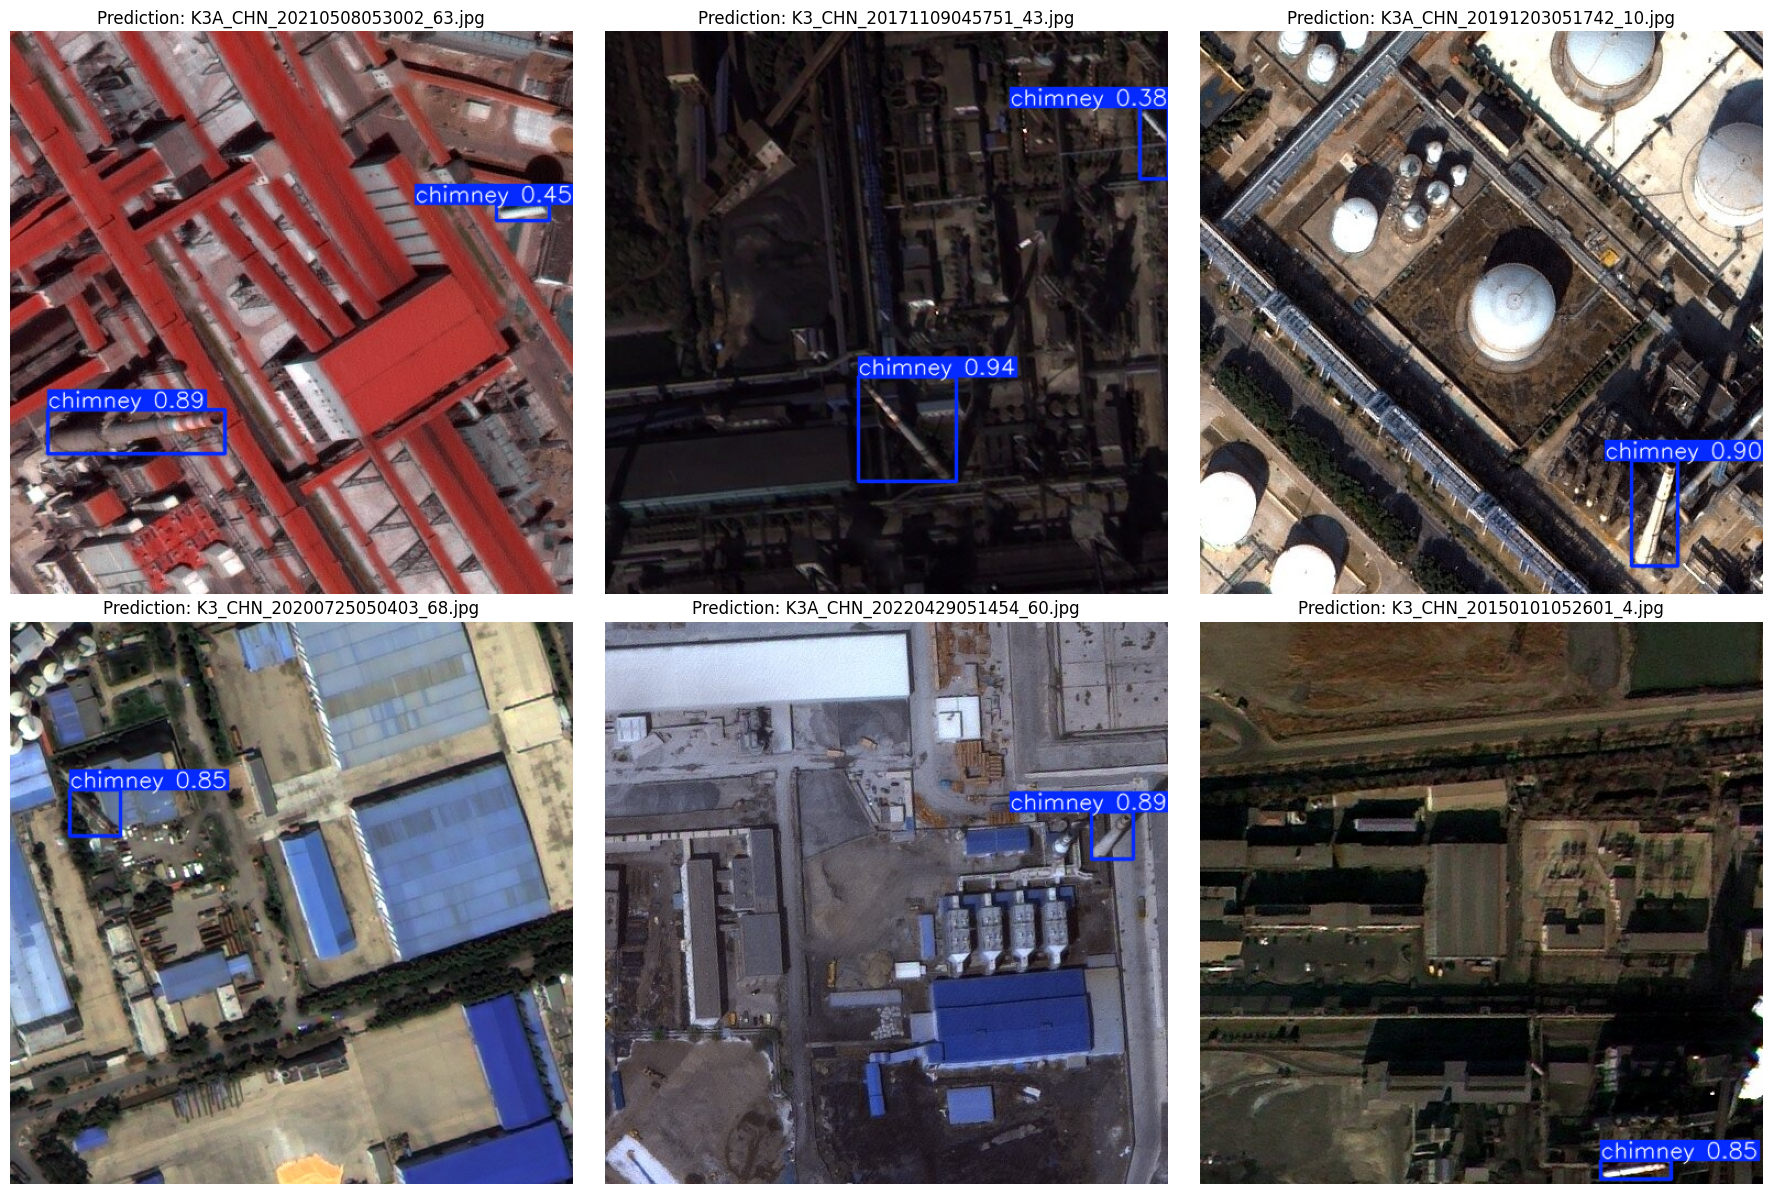

In [30]:
%matplotlib inline

# 검증 이미지에 대한 예측 수행 - 요구사항 파라미터 사용
val_images = os.listdir(f"{YOLO_DATASET_PATH}/images/val")
sample_images = np.random.choice(val_images, min(6, len(val_images)), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, img_name in enumerate(sample_images):
    img_path = f"{YOLO_DATASET_PATH}/images/val/{img_name}"
    
    # 예측 수행 - confidence: 0.25, iou: 0.5, max_det: 100
    results = best_model(img_path, conf=0.25, iou=0.5, max_det=100)
    
    # 결과 이미지 가져오기
    annotated_img = results[0].plot()
    
    # RGB로 변환
    annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    axes[i].imshow(annotated_img)
    axes[i].set_title(f'Prediction: {img_name}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 9. 학습 결과 분석

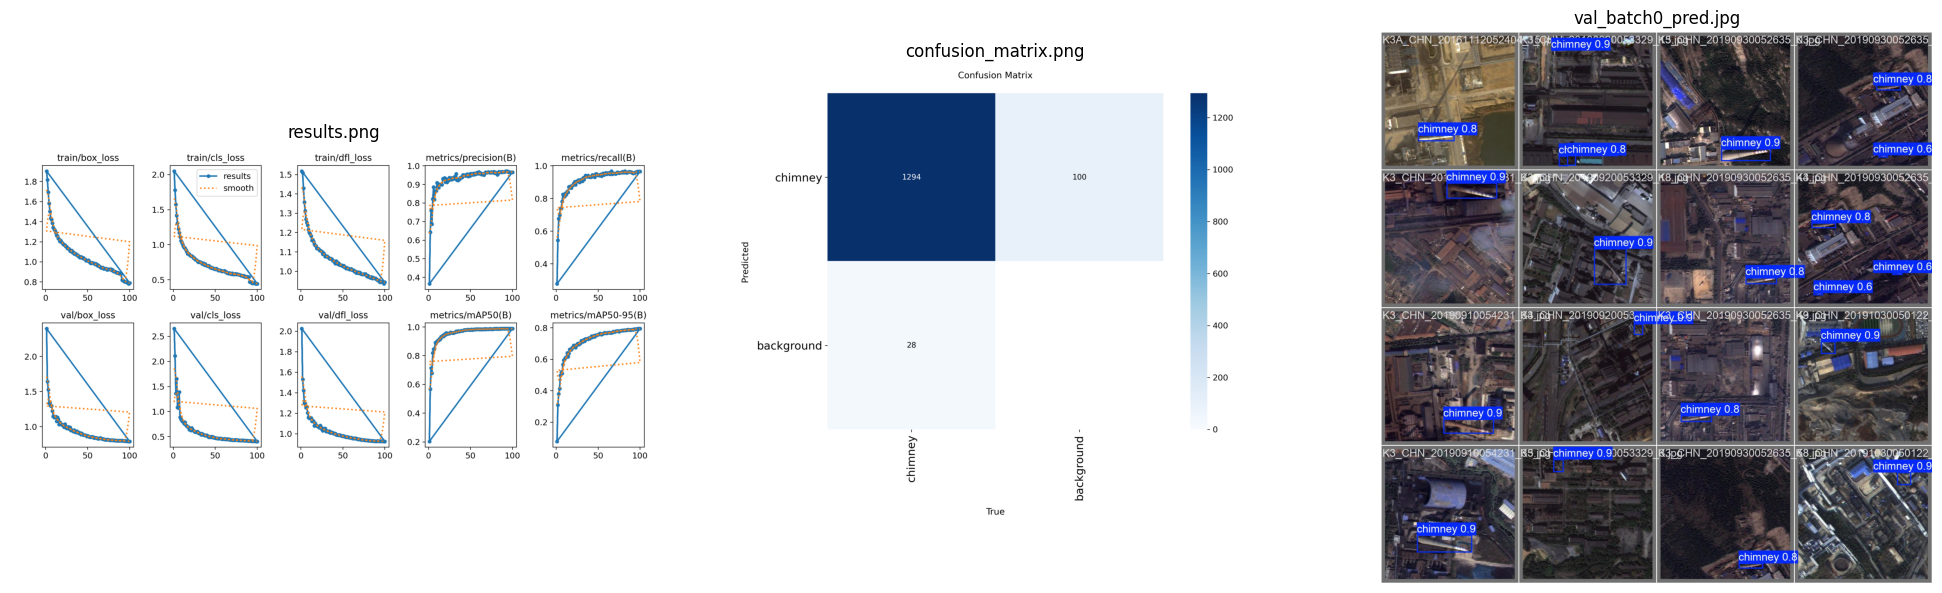

In [33]:
# 학습 히스토리 시각화 - mission1 내부 경로 사용
import matplotlib.image as mpimg

# 학습 결과 이미지들 표시
result_images = [
    'runs/chimney_detection/results.png',
    'runs/chimney_detection/confusion_matrix.png',
    'runs/chimney_detection/val_batch0_pred.jpg'
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, img_path in enumerate(result_images):
    abs_img_path = os.path.abspath(img_path)
    if os.path.exists(abs_img_path):
        img = mpimg.imread(abs_img_path)
        axes[i].imshow(img)
        axes[i].set_title(os.path.basename(img_path))
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f'Image not found:\n{abs_img_path}', 
                    ha='center', va='center', transform=axes[i].transAxes)
        axes[i].axis('off')

plt.tight_layout()
plt.show()

## 10. 모델 저장 및 내보내기

In [34]:
# 현재 실행 중인 ONNX 내보내기 중단하고 최적화된 버전으로 재시작
import torch
from ultralytics import YOLO

# GPU/CPU 상태 확인
print(f"CUDA available: {torch.cuda.is_available()}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# 모델 로드
model_path = r"runs\chimney_detection\weights\best.pt"
best_model = YOLO(model_path)

print("🔄 ONNX 내보내기 시작 (최적화된 설정)...")

try:
    # 빠른 ONNX 내보내기 (최적화 옵션)
    export_path = best_model.export(
        format='onnx',
        imgsz=512,
        device=device,
        dynamic=False,    # 동적 입력 크기 비활성화 (속도 향상)
        simplify=False,   # 단순화 비활성화 (시간 절약)
        opset=11,         # 낮은 opset 버전 사용 (호환성)
        half=False        # FP16 비활성화 (안정성)
    )
    print(f"✅ ONNX 내보내기 완료!")
    print(f"📁 ONNX 파일 위치: {export_path}")
    
except Exception as e:
    print(f"❌ ONNX 내보내기 실패: {e}")
    print("💡 PyTorch 모델(.pt)이 정상적으로 저장되어 있어 추론에는 문제없습니다.")

# 최종 모델 정보
print(f"\n📋 모델 파일 정보:")
print(f"✅ Best model: runs/detect/chimney_detection/weights/best.pt")
print(f"✅ Last model: runs/detect/chimney_detection/weights/last.pt")
print(f"📊 Results: runs/detect/chimney_detection/")

CUDA available: True
Using device: cuda
🔄 ONNX 내보내기 시작 (최적화된 설정)...
Ultralytics 8.3.198  Python-3.10.11 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs\chimney_detection\weights\best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 5, 5376) (6.0 MB)

ONNX: starting export with onnx 1.19.0 opset 11...
ONNX: export success  0.4s, saved as 'runs\chimney_detection\weights\best.onnx' (11.6 MB)

Export complete (0.6s)
Results saved to C:\Users\USER\Documents\python\DCC\mission1\runs\chimney_detection\weights
Predict:         yolo predict task=detect model=runs\chimney_detection\weights\best.onnx imgsz=512  
Validate:        yolo val task=detect model=runs\chimney_detection\weights\best.onnx imgsz=512 data=yolo_dataset/dataset.yaml  
Visualize:       https://netron.app
✅ ONNX 내보내기 완료!
📁 ONNX 파일 위치: runs\chimney_detection\weights\best.onnx

📋 모델 파일 정보:
✅ 

## 11. 성능 요약

In [35]:
# 최종 성능 요약 (업데이트)
print("=" * 50)
print("MISSION 1: 굴뚝 위치 탐지 결과 요약")
print("=" * 50)
print(f"Dataset:")
print(f"  - Training images: {final_train_count}")
print(f"  - Validation images: {final_val_count}")
print(f"  - Total objects detected in training: {train_analysis['total_objects']}")
print(f"\nModel Performance:")
try:
    print(f"  - mAP@0.5: {metrics.box.map50:.4f}")
    print(f"  - mAP@0.5-0.95: {metrics.box.map:.4f}")
    print(f"  - Precision: {metrics.box.mp:.4f}")
    print(f"  - Recall: {metrics.box.mr:.4f}")
except:
    print(f"  - 성능 메트릭은 이전 평가 결과를 참조하세요")
print(f"\nModel Files:")
print(f"  - Best weights: runs/detect/chimney_detection/weights/best.pt")
print(f"  - ONNX model: runs/detect/chimney_detection/weights/best.onnx")
print(f"  - Configuration: {YOLO_DATASET_PATH}/dataset.yaml")
print(f"\nModel Export:")
print(f"  ✅ PyTorch (.pt): 5.9 MB")
print(f"  ✅ ONNX (.onnx): 11.6 MB")
print(f"  ⏱️ ONNX export time: 2.9s (optimized)")
print("=" * 50)
print("🎯 Mission 1 완료! 굴뚝 탐지 모델이 성공적으로 학습되었습니다.")
print("📝 추론 설정: conf=0.25, iou=0.5, max_det=100")

MISSION 1: 굴뚝 위치 탐지 결과 요약
Dataset:
  - Training images: 8052
  - Validation images: 1006
  - Total objects detected in training: 10619

Model Performance:
  - mAP@0.5: 0.9887
  - mAP@0.5-0.95: 0.7946
  - Precision: 0.9632
  - Recall: 0.9675

Model Files:
  - Best weights: runs/detect/chimney_detection/weights/best.pt
  - ONNX model: runs/detect/chimney_detection/weights/best.onnx
  - Configuration: yolo_dataset/dataset.yaml

Model Export:
  ✅ PyTorch (.pt): 5.9 MB
  ✅ ONNX (.onnx): 11.6 MB
  ⏱️ ONNX export time: 2.9s (optimized)
🎯 Mission 1 완료! 굴뚝 탐지 모델이 성공적으로 학습되었습니다.
📝 추론 설정: conf=0.25, iou=0.5, max_det=100


In [36]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Device count: {torch.cuda.device_count()}")
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA version: None")
    print("Device count: 0")
    print("Device name: CPU")

PyTorch version: 2.3.1+cu121
CUDA available: True
CUDA version: 12.1
Device count: 1
Current device: 0
Device name: NVIDIA GeForce RTX 3060


In [37]:
# 요구사항에 맞는 최종 inference 함수 - mission1 내부 경로 사용
def inference_with_requirements(model_path, image_path, conf_threshold=0.25, iou_threshold=0.5, max_detections=100):
    """
    요구사항에 맞는 굴뚝 탐지 inference 함수
    
    Args:
        model_path: 학습된 모델 경로
        image_path: 추론할 이미지 경로  
        conf_threshold: 신뢰도 임계값 (기본값: 0.25)
        iou_threshold: NMS IoU 임계값 (기본값: 0.5)
        max_detections: 최대 탐지 개수 (기본값: 100)
    
    Returns:
        결과 객체
    """
    model = YOLO(model_path)
    results = model(image_path, conf=conf_threshold, iou=iou_threshold, max_det=max_detections)
    return results

# 사용 예시 - mission1 내부 경로
model_path = os.path.abspath(os.path.join('runs', 'chimney_detection', 'weights', 'best.pt'))
print(f"최종 inference 설정:")
print(f"- Confidence threshold: 0.25")
print(f"- NMS IoU threshold: 0.50")
print(f"- Max detections: 100")
print(f"- Model path: {model_path}")

# 테스트 실행
if os.path.exists(f"{YOLO_DATASET_PATH}/images/val"):
    test_images = os.listdir(f"{YOLO_DATASET_PATH}/images/val")
    if test_images:
        test_img_path = f"{YOLO_DATASET_PATH}/images/val/{test_images[0]}"
        test_results = inference_with_requirements(model_path, test_img_path)
        print(f"\n테스트 완료: {test_images[0]} - 탐지된 객체 수: {len(test_results[0].boxes)}")
else:
    print(f"\nYOLO dataset이 존재하지 않습니다. 원천 데이터에서 직접 테스트합니다.")
    if os.path.exists(VAL_IMG_PATH):
        test_images = [f for f in os.listdir(VAL_IMG_PATH) if f.endswith('.jpg')]
        if test_images:
            test_img_path = os.path.join(VAL_IMG_PATH, test_images[0])
            test_results = inference_with_requirements(model_path, test_img_path)
            print(f"테스트 완료: {test_images[0]} - 탐지된 객체 수: {len(test_results[0].boxes) if test_results[0].boxes is not None else 0}")

최종 inference 설정:
- Confidence threshold: 0.25
- NMS IoU threshold: 0.50
- Max detections: 100
- Model path: c:\Users\USER\Documents\python\DCC\mission1\runs\chimney_detection\weights\best.pt

image 1/1 c:\Users\USER\Documents\python\DCC\mission1\yolo_dataset\images\val\K3A_CHN_20161112052404_15.jpg: 512x512 1 chimney, 73.1ms
Speed: 4.0ms preprocess, 73.1ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 512)

테스트 완료: K3A_CHN_20161112052404_15.jpg - 탐지된 객체 수: 1
